In [3]:
import os

**Dataset Link**
https://www.kaggle.com/datasets/rukenmissonnier/manufacturing-data-for-polynomial-regression

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [5]:
# Load the dataset
df = pd.read_csv("/kaggle/input/manufacturing-data-for-polynomial-regression/manufacturing.csv")
df.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [6]:
# Preview the datatypes and null values
print(df.dtypes)
print(df.isnull().sum())

Temperature (°C)                  float64
Pressure (kPa)                    float64
Temperature x Pressure            float64
Material Fusion Metric            float64
Material Transformation Metric    float64
Quality Rating                    float64
dtype: object
Temperature (°C)                  0
Pressure (kPa)                    0
Temperature x Pressure            0
Material Fusion Metric            0
Material Transformation Metric    0
Quality Rating                    0
dtype: int64


In [7]:
# Copy the contents of dataset in original and copies
df_original = df.copy()
df_copy = df.copy()
print("Data copied successfully")

Data copied successfully


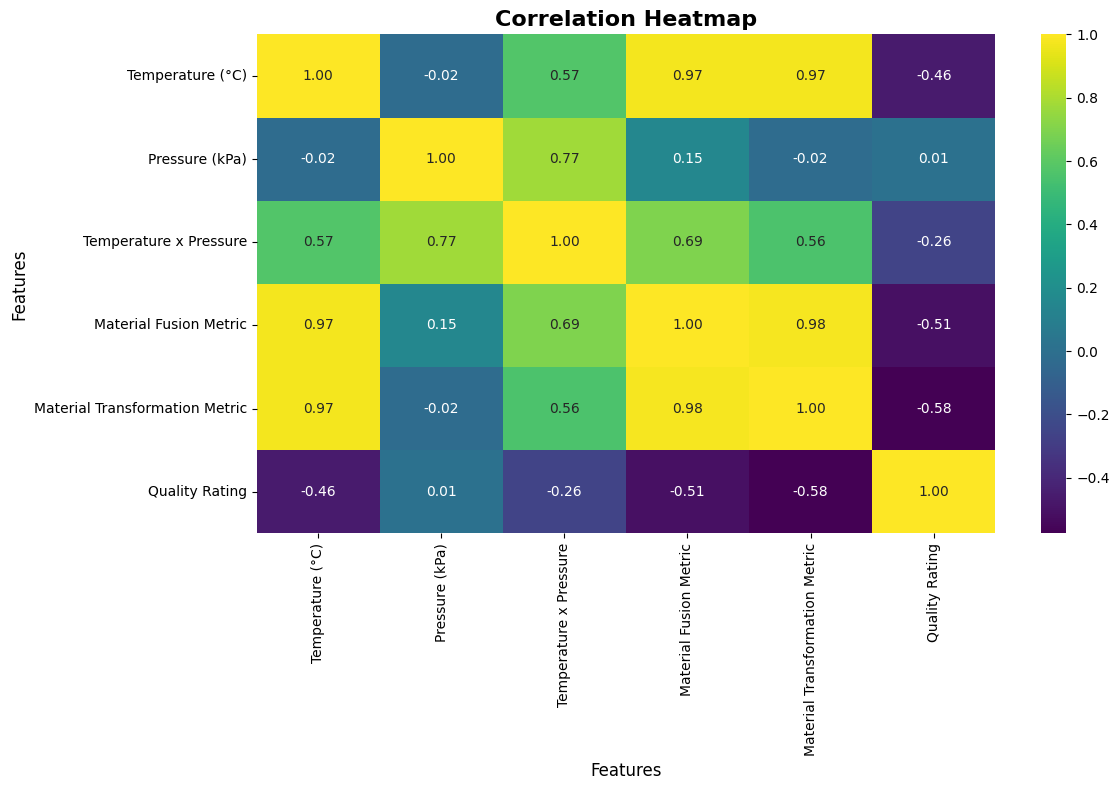

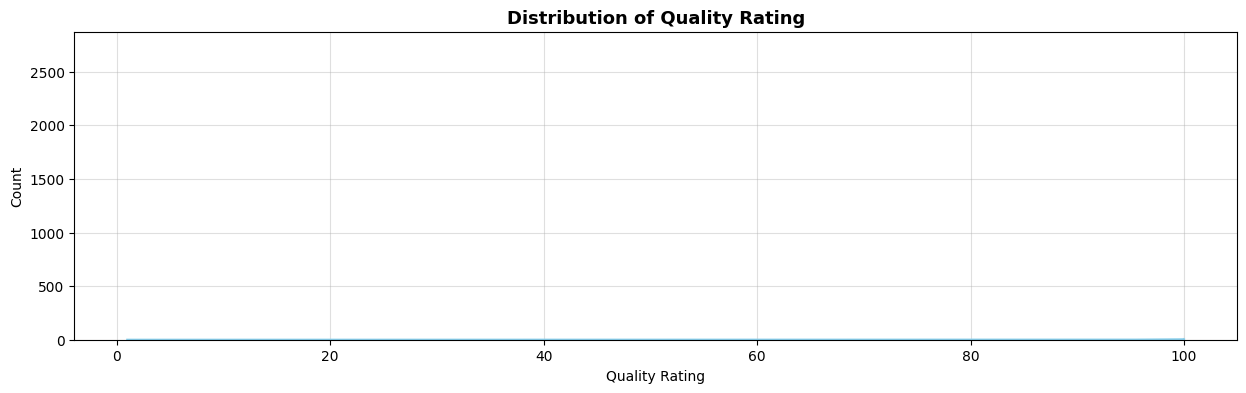

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_copy.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

# Distribution of Quality Rating
plt.figure(figsize=(15, 4))
sns.histplot(df_copy['Quality Rating'], kde=True, color='skyblue')
plt.title("Distribution of Quality Rating", fontsize=13, fontweight='bold')
plt.xlabel("Quality Rating")
plt.ylabel("Count")
plt.grid(True, alpha=0.4)
plt.show()

In [10]:
# Extract the independent and depenedent variables
X = df.drop(columns=['Quality Rating'])
y = df['Quality Rating']

# Split into  Train and test the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Optuna objective function
def objective(trial):
    # Suggest Hyperparameters 
    degree = trial.suggest_int('degree', 2,7)
    alpha = trial.suggest_float('alpha', 1e-4, 1.0, log=True)
    include_bias = trial.suggest_categorical('include_bias', [True, False])

    # Build a model
    model = Pipeline([
        ('poly', PolynomialFeatures(
            degree=degree,
            include_bias=include_bias
        )),
        ('ridge', Ridge(alpha=alpha))
    ])

    # Cross validation score for R2 demonstration
    score = cross_val_score(model, X_train_scaled, y_train, cv=5, n_jobs=-1, verbose=2)
    return np.mean(score)

In [12]:
# Optuna optimization 
import optuna 

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best Parameters:", study.best_params)
print("Best CV R² Score:", study.best_value)

best_params = study.best_params

# Train final model
best_poly_model = Pipeline([
    ('poly', PolynomialFeatures(
        degree = best_params['degree'],
        include_bias = best_params['include_bias']
    )),
    ('ridge', Ridge(alpha=best_params['alpha']))
])
best_poly_model.fit(X_train_scaled, y_train)

# Predict
y_pred = best_poly_model.predict(X_test_scaled)

[I 2025-10-30 16:08:29,583] A new study created in memory with name: no-name-09be3b08-7c40-4f8f-968f-ccb543f5d177


  0%|          | 0/30 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


[I 2025-10-30 16:08:31,764] Trial 0 finished with value: 0.9991803336297256 and parameters: {'degree': 5, 'alpha': 0.025952864843810017, 'include_bias': False}. Best is trial 0 with value: 0.9991803336297256.
[I 2025-10-30 16:08:31,939] Trial 1 finished with value: 0.9999605385914585 and parameters: {'degree': 6, 'alpha': 0.004157354069078774, 'include_bias': False}. Best is trial 1 with value: 0.9999605385914585.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


...

[I 2025-10-30 16:08:36,774] Trial 25 finished with value: 0.9999986661141576 and parameters: {'degree': 7, 'alpha': 0.0003386565294107211, 'include_bias': True}. Best is trial 24 with value: 0.9999992082430398.
[I 2025-10-30 16:08:36,929] Trial 26 finished with value: 0.9999714060168927 and parameters: {'degree': 6, 'alpha': 0.0007552580141729262, 'include_bias': True}. Best is trial 24 with value: 0.9999992082430398.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


[I 2025-10-30 16:08:37,008] Trial 27 finished with value: 0.9996362491562591 and parameters: {'degree': 5, 'alpha': 0.001970140178728326, 'include_bias': True}. Best is trial 24 with value: 0.9999992082430398.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished


[I 2025-10-30 16:08:37,335] Trial 28 finished with value: 0.9999989542892058 and parameters: {'degree': 7, 'alpha': 0.00020185643983711493, 'include_bias': True}. Best is trial 24 with value: 0.9999992082430398.
[I 2025-10-30 16:08:37,424] Trial 29 finished with value: 0.9990249755264525 and parameters: {'degree': 5, 'alpha': 0.06780359661675997, 'include_bias': True}. Best is trial 24 with value: 0.9999992082430398.
Best Parameters: {'degree': 7, 'alpha': 0.00010084749992712345, 'include_bias': True}
Best CV R² Score: 0.9999992082430398


In [13]:
# Evolution metric function
def evoluate_model(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mae)
    r2 = r2_score(y_test, y_pred)
    return mse, mae, rmse, r2

print("Model metrics : ", evoluate_model(y_test, y_pred))

Model metrics :  (8.706287369049948e-05, 0.006624959542153866, 0.08139385444954592, 0.9999995735360532)


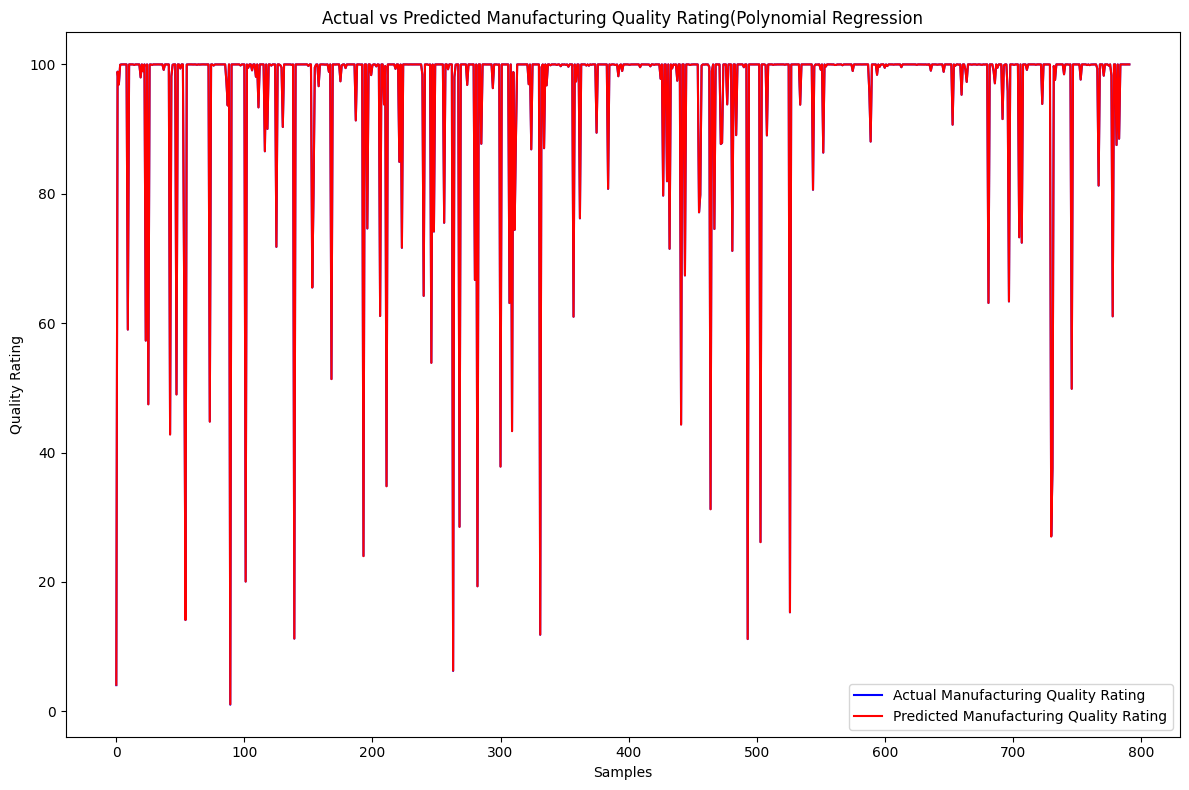

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual vs predicted
plt.figure(figsize=(12,8))
plt.plot(y_test.values, label='Actual Manufacturing Quality Rating', color='blue')
plt.plot(y_pred, label='Predicted Manufacturing Quality Rating', color='red')
plt.title('Actual vs Predicted Manufacturing Quality Rating(Polynomial Regression')
plt.xlabel('Samples')
plt.ylabel('Quality Rating')
plt.legend()
plt.tight_layout()
plt.show()

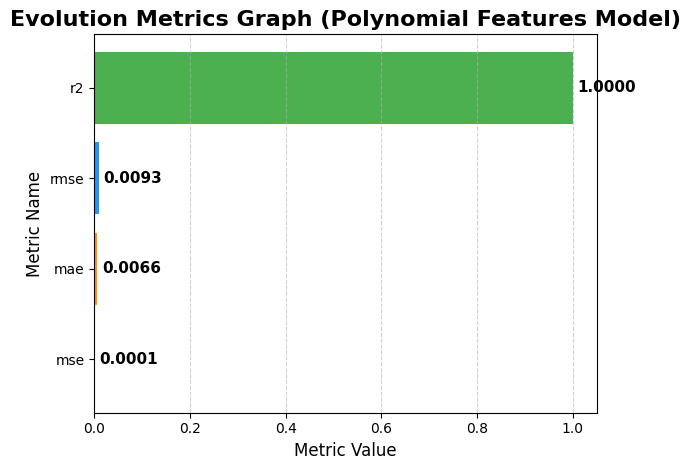

In [77]:
metrics = {
    'mse':mean_squared_error(y_test, y_pred),
    'mae':mean_absolute_error(y_test, y_pred),
    'rmse':np.sqrt(mean_squared_error(y_test, y_pred)),
    'r2':r2_score(y_test, y_pred)
}
# Horizontal bar chart for better readability
plt.barh(list(metrics.keys()), list(metrics.values()), color=['#4CAF50', '#FF9800', '#2196F3'])

# Title and labels
plt.title('Evolution Metrics Graph (Polynomial Features Model)', fontsize=16, fontweight='bold')
plt.xlabel('Metric Value', fontsize=12)
plt.ylabel('Metric Name', fontsize=12)

# Add metric values beside bars
for i, (key, value) in enumerate(metrics.items()):
    plt.text(value + 0.01, i, f"{value:.4f}", va='center', fontsize=11, fontweight='bold')

# Grid and style
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [90]:
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_parallel_coordinate,
    plot_contour,
    plot_edf
)

# Basic summary
best_params = study.best_params
best_score = study.best_value

print("Best Parameters:", best_params)
print("Best CV R² Score:", best_score)

# Generate and save PNG plots
plots = {
    "optimization_history": plot_optimization_history(study),
    "param_importances": plot_param_importances(study),
    "parallel_coordinate": plot_parallel_coordinate(study),
    "contour": plot_contour(study),
    "slice": plot_slice(study),
    "edf": plot_edf(study)
}

# Show and save plots
for name, fig in plots.items():
    fig.show()

Best Parameters: {'degree': 7, 'alpha': 0.00010140534368293074, 'include_bias': True}
Best CV R² Score: 0.9999992067536135


In [101]:
for name, fig in plots.items():
    fig.write_html(f"{name}.html")

In [59]:
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Create the pipeline
pipe = make_pipeline(StandardScaler(), best_poly_model)
pipe.fit(X_train, y_train)

# Save the trained pipeline
joblib.dump(pipe, "polynomial_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!


In [65]:
df.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [64]:
loaded_pipe = joblib.load("polynomial_pipeline.pkl")

new_data = pd.DataFrame({
    "Temperature (°C)": [209.762701, 243.037873, 220.552675, 208.976637, 184.730960],
    "Pressure (kPa)": [8.050855, 15.812068, 7.843130, 23.786089, 15.797812],
    "Temperature x Pressure": [1688.769167, 3842.931469, 1729.823314, 4970.736918, 2918.345014],
    "Material Fusion Metric": [44522.217074, 63020.764997, 49125.950249, 57128.881547, 38068.201283],
    "Material Transformation Metric": [9.229576e+06, 1.435537e+07, 1.072839e+07, 9.125702e+06, 6.303792e+06],
})

y_pred = loaded_pipe.predict(new_data)
y_pred

array([100.00232322,  99.97028818, 100.00976238, 100.00193167,
        99.99561176])